# Section A: Basic Python

In [1]:
#A
country = "Malaysia"
population = 33000000
print(f"The population of {country} is {population:,}.")

The population of Malaysia is 33,000,000.


In [2]:
#B
numbers = [12, 15, 18, 21, 24, 27, 30, 33, 36, 39]
print(f"Minimum of the list is {min(numbers)}")
print(f"Maximum of the list is {max(numbers)}")
print(f"Sum of the list is {sum(numbers)}")

print(numbers[1:4])

sum_of_even = 0
for x in numbers:
    if x % 2 == 0:
        sum_of_even += x
        
print(f"Sum of all even numbers is {sum_of_even}")

Minimum of the list is 12
Maximum of the list is 39
Sum of the list is 255
[15, 18, 21]
Sum of all even numbers is 120


In [3]:
#C
data = {
    'key1': [1, 2, 3,
        {'nested_key': ['a', 'b', 'c',
                {'target': [10, 20, 30, 'hello']
                }
            ]
        }
    ]
}

#Use indexing to grab nested_key nested dictionary.
nested_dict = data['key1'][3] 
print(nested_dict)

#Use indexing to grab the word "hello."
hello = data['key1'][3]['nested_key'][3]['target'][3]
print(hello) 

#Change the word “hello” to 40.
hello = 40
print(data) 

{'nested_key': ['a', 'b', 'c', {'target': [10, 20, 30, 'hello']}]}
hello
{'key1': [1, 2, 3, {'nested_key': ['a', 'b', 'c', {'target': [10, 20, 30, 'hello']}]}]}


In [4]:
#D
def count_vowels(s):
    count = 0
    for x in s:
        if x=='a' or x=='e' or x=='i' or x=='o' or x=='u' or x=='A' or x=='E' or x=='I' or x=='O' or x=='U' :
            count += 1
    print(f"The number of vowels in the string is: {count}")

string = input("Enter your string: ")
count_vowels(string)
string = input("Enter your string: ")
count_vowels(string)

Enter your string:  Artificial Intelligence


The number of vowels in the string is: 10


Enter your string:  Data Management


The number of vowels in the string is: 6


In [5]:
#E
import numpy as np
array1 = np.zeros(10)
print(array1)
array2 = np.arange(11, 51, 2) #(start, end (not included), step)
print(array2)
array3 = np.array([[1,0,0],[0,1,0],[0,0,1]])
print(array3)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47 49]
[[1 0 0]
 [0 1 0]
 [0 0 1]]


# Section B: Data Analysis

In [21]:
#A
import pandas as pd
file_loaction = r"C:\University\Year 3 Sem 1\Data Mining\Assignment\student_data.csv"
df = pd.read_csv(file_loaction)
display(df.head(5))

,Name,Age,Grade,Subject
0,Zhang Lei,21.0,2.62,Biology
1,Nadia Binti Hassan,20.0,3.14,Art
2,Khalid Nasir,16.0,3.27,Physics
3,Chen Jie,16.0,3.12,Physics
4,Mohd Faiz,NaN,2.24,Biology


In [22]:
#B
missing_data = df.isnull()
missing_data.head(5)

,Name,Age,Grade,Subject
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,True,False,False


In [23]:
print(df.isnull().sum())

Name       0
Age        1
Grade      1
Subject    1
dtype: int64


In [24]:
df.dropna(subset = ['Subject'], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)

avg_age = df["Age"].astype("float").mean(axis=0)
df["Age"] = df["Age"].replace(np.nan, avg_age)

avg_grade = df["Grade"].astype("float").mean(axis=0)
df["Grade"] = df["Grade"].replace(np.nan, avg_grade)


print(df.isnull().sum())

Name       0
Age        0
Grade      0
Subject    0
dtype: int64


In [25]:
df

,Name,Age,Grade,Subject
0,Zhang Lei,21.000000,2.62,Biology
1,Nadia Binti Hassan,20.000000,3.14,Art
2,Khalid Nasir,16.000000,3.27,Physics
3,Chen Jie,16.000000,3.12,Physics
4,Mohd Faiz,18.816327,2.24,Biology
...,...,...,...,...
94,Yusuf Kareem,20.000000,2.14,Art
95,Wu Hao,18.000000,2.64,Computer Science
96,Hafizul Rahman,18.000000,3.58,Art
97,Ali Hassan,22.000000,3.20,History


In [26]:
#C
#i. The average age of students.
print(f"The average age of students is {df['Age'].mean()}.")

The average age of students is 18.816326530612244.


In [27]:
#ii. The name of the student with the highest grade.
highest_grade_row = df.loc[df['Grade'].idxmax()]
print(f"The name of the student with the highest grade is {highest_grade_row['Name']}.")

The name of the student with the highest grade is Azman Hakim.


In [28]:
#iii. The number of students who are older than 20.
older_than_20 = df[df['Age'] > 20]
count = len(older_than_20)
print(f"The number of students who are older than 20 is {count}.")

The number of students who are older than 20 is 33.


In [29]:
#iv. The percentage of students who have a grade above 3.8.
grade_A = df[df['Grade'] > 3.80]
percentage = (len(grade_A) / len(df)) * 100
print(f"The percentage of students who have a grade above 3.8 is {percentage:.2f} %.")

The percentage of students who have a grade above 3.8 is 7.07 %.


In [30]:
#v. The most common subject among students.
most_common_subject = df['Subject'].mode()[0]
print(f"The most common subject among students is {most_common_subject}.")

The most common subject among students is Computer Science.


In [31]:
#vi. Who is the youngest student?
youngest_student_row = df.loc[df['Age'].idxmin()]
print(f"The youngest student is {youngest_student_row['Name']}.")

The youngest student is Ahmad Hafiz.


In [32]:
#vii. What is the average grade per subject?
average_grade_per_subject = df.groupby('Subject')['Grade'].mean().round(2)
print(f"The average grade per subject is：")
display(average_grade_per_subject)

The average grade per subject is：


Subject
Art                 3.01
Biology             3.02
Chemistry           3.37
Computer Science    2.89
Economics           3.14
English             3.15
Geography           2.85
History             3.20
Mathematics         2.90
Physics             3.00
Name: Grade, dtype: float64

In [33]:
#viii. How many students are enrolled in each subject?
students_per_subject = df['Subject'].value_counts()
print("Number of students enrolled in each subject: ")
display(students_per_subject)

Number of students enrolled in each subject: 


Subject
Physics             14
Computer Science    14
Geography           12
Biology             11
Art                 11
Mathematics         11
History              9
Chemistry            7
English              5
Economics            5
Name: count, dtype: int64

In [34]:
#ix. Who are the students with grades below 2.5?
grade_C = df[df['Grade'] < 2.50]['Name']
print("Students with grades below 2.5: ")
print(grade_C.to_string(index=False))

Students with grades below 2.5: 
         Mohd Faiz
            Li Wei
          Chen Jie
Nadia Binti Hassan
        Zainab Ali
          Zhou Lin
       Roslan Amir
          Zhao Rui
      Hana Youssef
          Zhou Lin
        Zainab Ali
       Aisha Ahmed
       Omar Khaled
            Xu Yan
       Azman Hakim
      Samira Fadel
            Li Wei
         Mohd Faiz
       Aisha Ahmed
            Li Wei
       Aisha Ahmed
            Wu Hao
         Mohd Faiz
        Zainab Ali
      Yusuf Kareem


In [35]:
#x. What is the median grade of students?
median_grade = df['Grade'].median()
print(f"The median grade of students is {median_grade}")

The median grade of students is 3.14


# Section C: Data Preprocessing

In [21]:
#1 #f,g
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df2 = sns.load_dataset('titanic')
display(df2.head(5))
display(df2.tail(10))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


In [22]:
#h
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [23]:
df2.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
#h
df2.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [25]:
print(df2.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [26]:
#i
#replace by mean
avg_age = df2["age"].mean()
df2['age'] = df2['age'].replace(np.nan, avg_age)

In [27]:
df2['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [28]:
#replace by the most frequent
df2['embarked'] = df2['embarked'].replace(np.nan, 'S')
df2['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [29]:
df2['deck'].value_counts()

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

In [30]:
#drop the whole column
df2.drop(columns=['deck'], inplace=True)

In [31]:
df2['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [32]:
#replace by the most frequent
df2['embark_town'] = df2['embark_town'].replace(np.nan, 'Southampton')
df2['embark_town'].value_counts()

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [33]:
print(df2.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [34]:
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [35]:
#drop redundant column
redundant_columns = ['embark_town', 'alive', 'who', 'class', 'adult_male']
df2.drop(columns = redundant_columns, axis = 1, inplace = True)
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.000000,1,0,7.2500,S,False
1,1,1,female,38.000000,1,0,71.2833,C,False
2,1,3,female,26.000000,0,0,7.9250,S,True
3,1,1,female,35.000000,1,0,53.1000,S,False
4,0,3,male,35.000000,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,True
887,1,1,female,19.000000,0,0,30.0000,S,True
888,0,3,female,29.699118,1,2,23.4500,S,False
889,1,1,male,26.000000,0,0,30.0000,C,True


In [36]:
# Convert 'alone' from boolean to int (True->1, False->0)
df2['alone'] = df2['alone'].astype(int)

numeric_columns = df2.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [37]:
import pandas as pd
#j. Convert categorical variables into numerical representations where applicable.
# One-Hot Encoding
binary_categorical_columns = ['sex']  # Columns with two categories
multi_categorical_columns = ['embarked']  # Columns with more than two categories

df2_multi_encoded = pd.get_dummies(df2[multi_categorical_columns], dtype = int)
df2_binary_encoded = pd.get_dummies(df2[binary_categorical_columns], dtype = int, 
                                   drop_first = True)


In [38]:
# 1. Define which columns were not encoded
non_encoded_columns = df2.drop(columns=binary_categorical_columns + multi_categorical_columns)

# 2. concat
df2_cleaned = pd.concat([non_encoded_columns, df2_binary_encoded, df2_multi_encoded], axis=1)
df2_cleaned

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.000000,1,0,7.2500,0,1,0,0,1
1,1,1,38.000000,1,0,71.2833,0,0,1,0,0
2,1,3,26.000000,0,0,7.9250,1,0,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,0,0,1
4,0,3,35.000000,0,0,8.0500,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,1,0,0,1
887,1,1,19.000000,0,0,30.0000,1,0,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,1,0,0


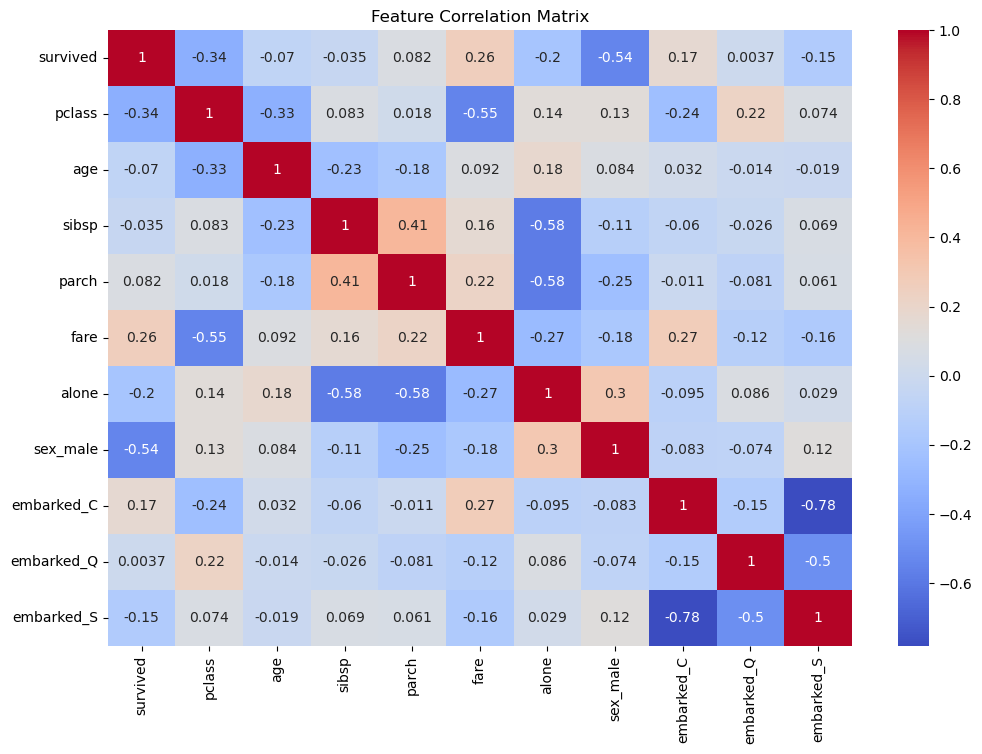

In [39]:
# k. Perform feature selection to identify relevant columns for analysis and machine learning.
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
sns.heatmap(df2_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [40]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df2_cleaned.drop("survived", axis=1)
y = df2_cleaned["survived"]

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)


selected_features = X.columns[selector.get_support()]
print("Top features:", selected_features)


Top features: Index(['pclass', 'fare', 'alone', 'sex_male', 'embarked_C'], dtype='object')


# 2. Data Visualization

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")  

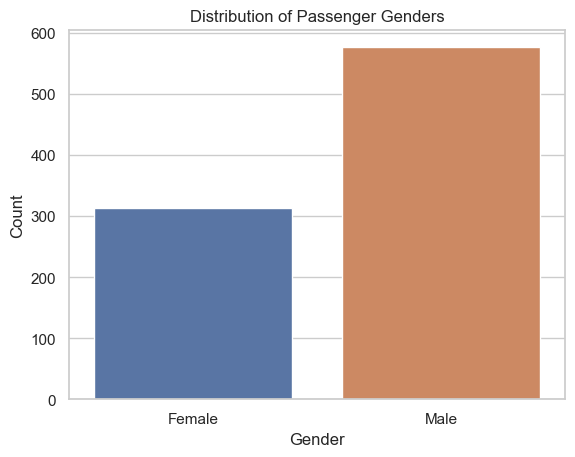

In [42]:
#a. Visualize the distribution of passengers’ genders (sex)
sns.countplot(x='sex_male', data=df2_cleaned)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Distribution of Passenger Genders")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


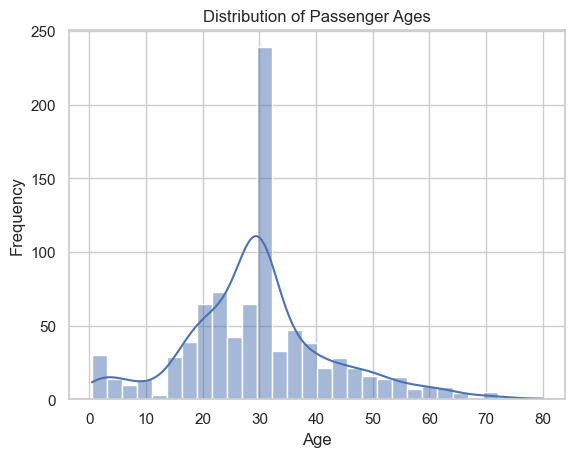

In [43]:
#b. Show the distribution of passengers’ ages (age).
sns.histplot(data=df2_cleaned, x='age', bins=30, kde=True)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


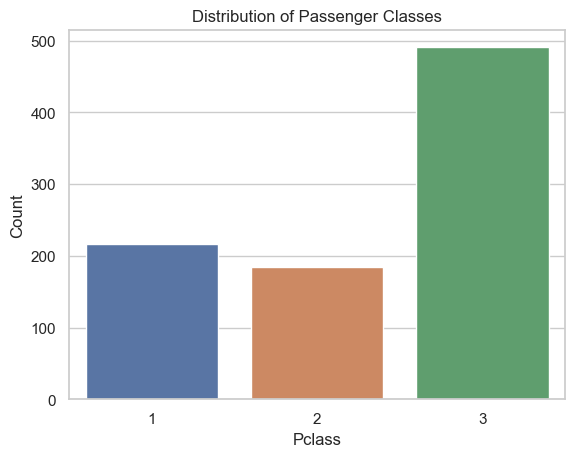

In [44]:
#c. Display the number of passengers in different classes (pclass).
sns.countplot(x='pclass', data=df2_cleaned)
plt.title("Distribution of Passenger Classes")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()


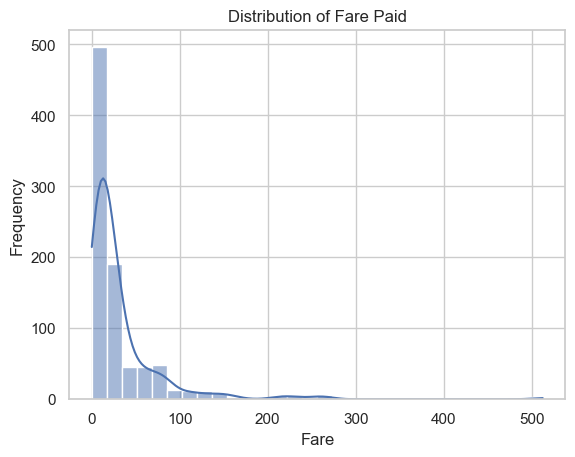

In [45]:
#d. Show the distribution of fares paid (fare)
sns.histplot(data=df2_cleaned, x='fare', bins=30, kde=True)
plt.title("Distribution of Fare Paid")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


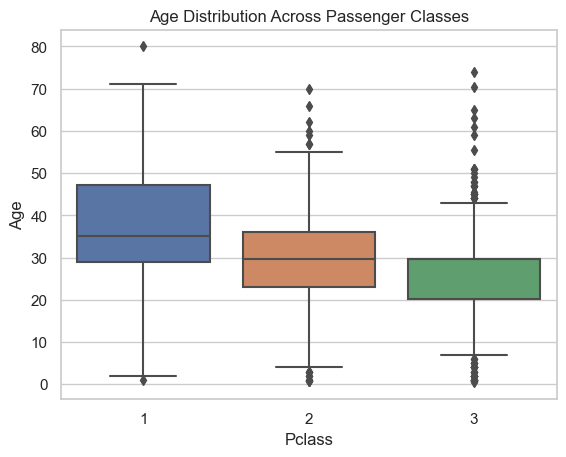

In [46]:
#e. Compare age distributions across different passenger classes (pclass).
sns.boxplot(x='pclass', y='age', data=df2_cleaned)
plt.title("Age Distribution Across Passenger Classes")
plt.xlabel("Pclass")
plt.ylabel("Age")
plt.show()


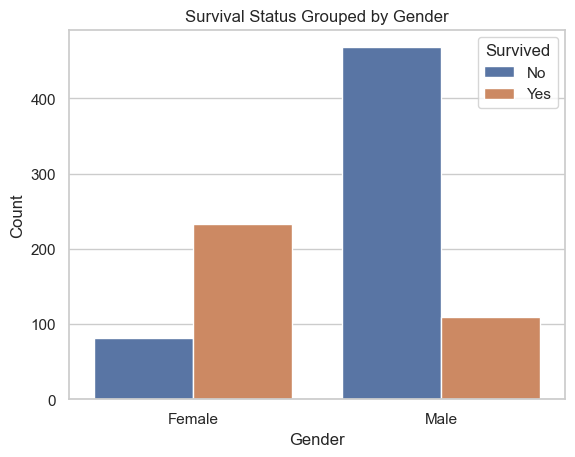

In [47]:
#f. Show survival status grouped by gender (sex).
sns.countplot(x='sex_male', hue='survived', data=df2_cleaned)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Survival Status Grouped by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


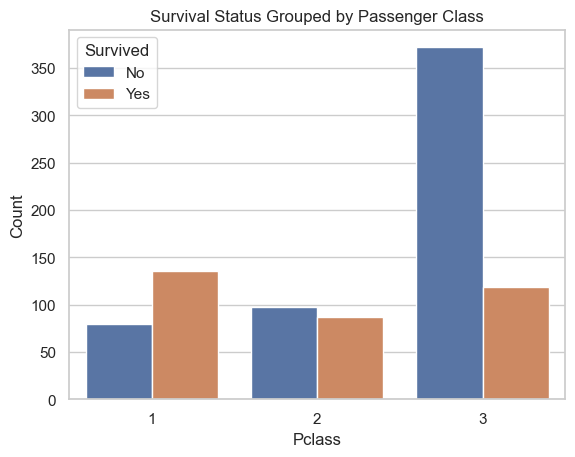

In [48]:
#g. Show survival status grouped by passenger class (pclass).
sns.countplot(x='pclass', hue='survived', data=df2_cleaned)
plt.title("Survival Status Grouped by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_29140\2613941907.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df2_cleaned[df2_cleaned['survived'] == 1]['age'], label='Survived', shade=True)
C:\Users\User\AppData\Local\Temp\ipykernel_29140\2613941907.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df2_cleaned[df2_cleaned['survived'] == 0]['age'], label='Not Survived', shade=True)


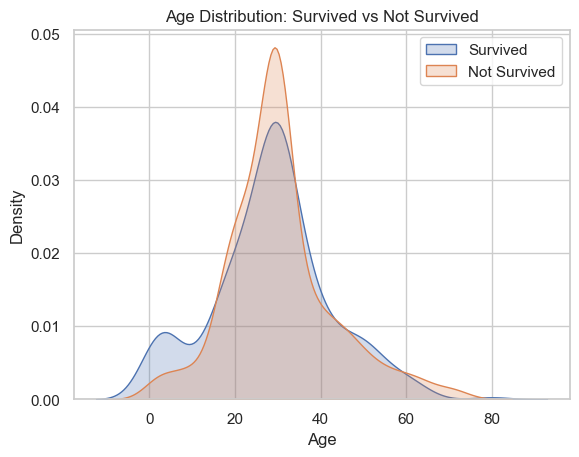

In [49]:
#h. Compare the age distribution of survivors and non-survivors.
sns.kdeplot(data=df2_cleaned[df2_cleaned['survived'] == 1]['age'], label='Survived', shade=True)
sns.kdeplot(data=df2_cleaned[df2_cleaned['survived'] == 0]['age'], label='Not Survived', shade=True)
plt.title("Age Distribution: Survived vs Not Survived")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()


# Section D: Machine Learning & Model Evaluation

# Supervised Learning

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


In [51]:
#1.
#a. Split the dataset into training (80%) and testing (20%) sets.
# Define features and target
X = df2_cleaned.drop(columns=["survived"])
y = df2_cleaned["survived"]

#Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [52]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

 Logistic Regression
Accuracy: 0.8045
Confusion Matrix:
[[90 15]
 [20 54]]
True Negatives: 90, False Positives: 15, False Negatives: 20, True Positives: 54
Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



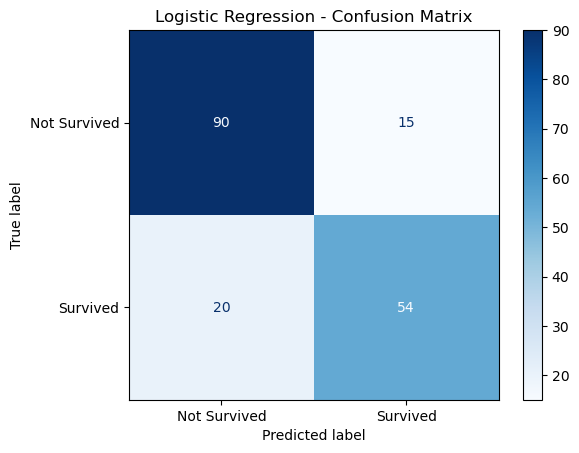

 Random Forest
Accuracy: 0.8268
Confusion Matrix:
[[93 12]
 [19 55]]
True Negatives: 93, False Positives: 12, False Negatives: 19, True Positives: 55
Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.89      0.86       105
    Survived       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



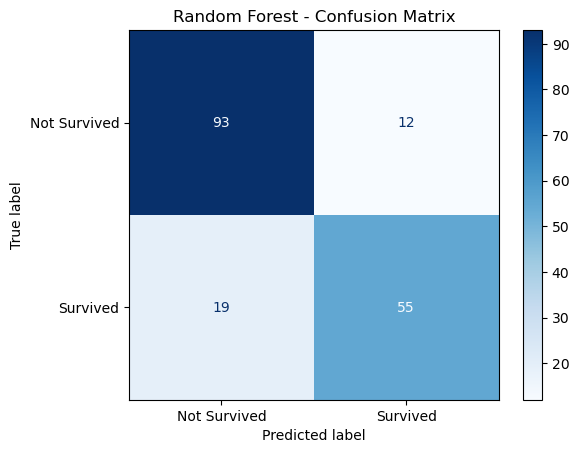

In [53]:
#b. Choose two machine learning algorithms to train a classification model.
#c. Evaluate the model using the confusion matrix.
# Build 2 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Fit, predict, and evaluate both models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f" {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")

    # Precision, Recall, F1-Score）
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))


    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


# Unsupervised Learning

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [55]:
#a. Select age, fare, and class as clustering features.
clustering_features = df2_cleaned[["age", "fare", "pclass"]]

In [56]:
# b. Scale the data for better clustering performance.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

In [57]:
#c. Apply K-Means clustering
inertia = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are les

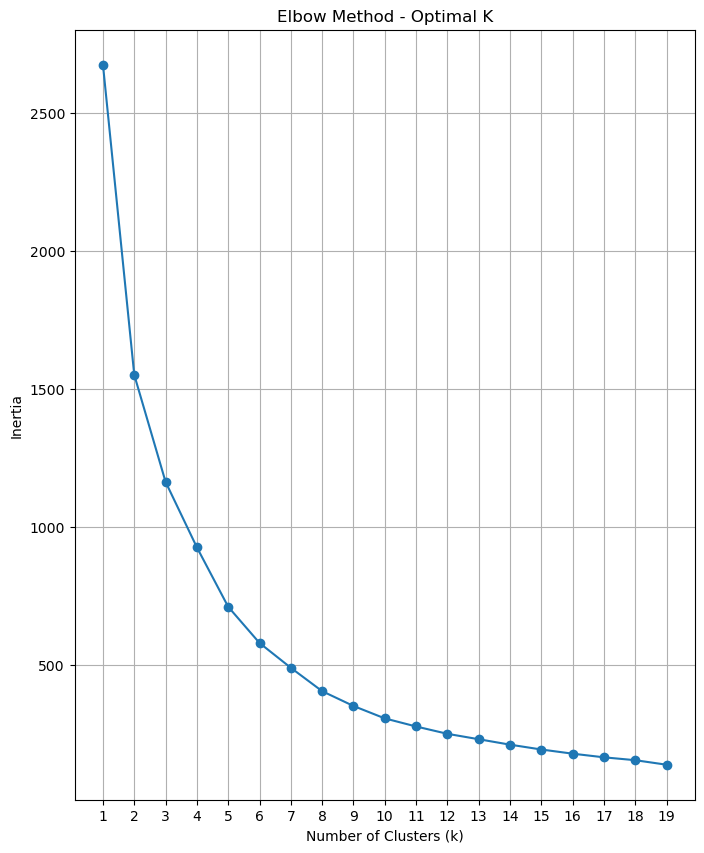

In [62]:
plt.figure(figsize=(8, 10))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method - Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.show()
#k=8, 10

In [63]:
optimal_k = 10
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_features)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [64]:
df2_cleaned["cluster"] = cluster_labels

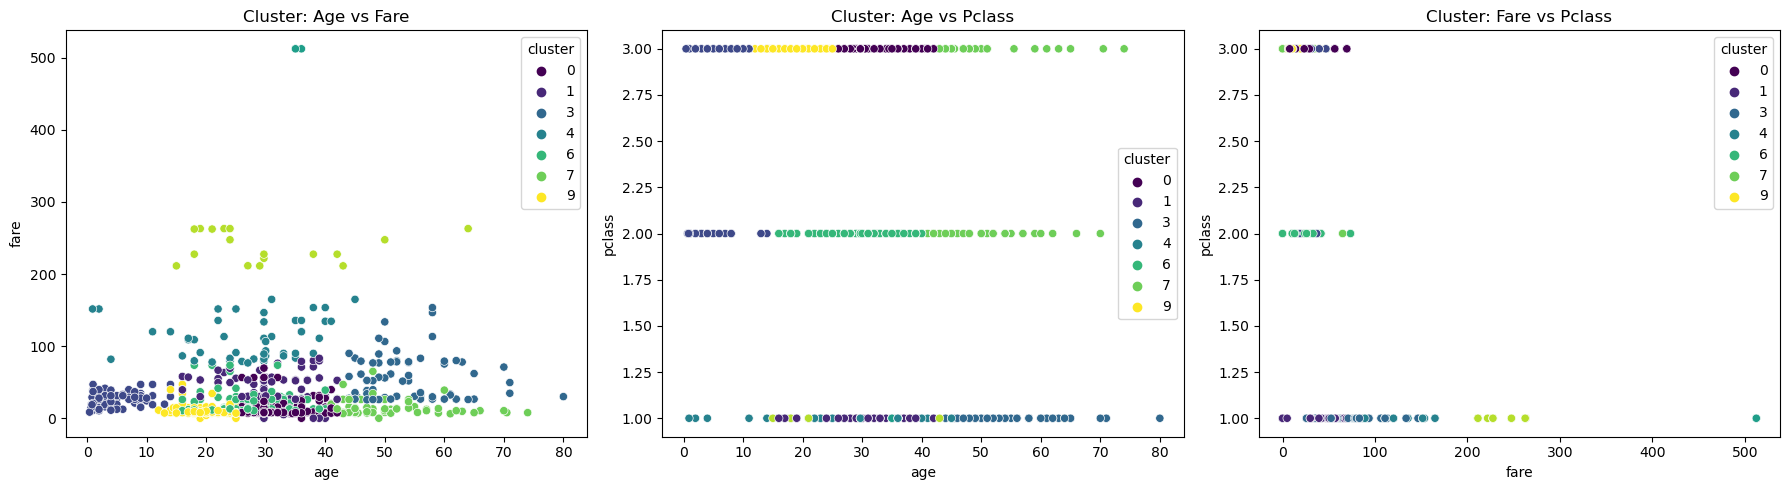

In [68]:
plt.figure(figsize=(18, 5))

# Age vs Fare
plt.subplot(1, 3, 1)
sns.scatterplot(data=df2_cleaned, x='age', y='fare', hue='cluster', palette='viridis')
plt.title('Cluster: Age vs Fare')

# Age vs Pclass
plt.subplot(1, 3, 2)
sns.scatterplot(data=df2_cleaned, x='age', y='pclass', hue='cluster', palette='viridis')
plt.title('Cluster: Age vs Pclass')

# Fare vs Pclass
plt.subplot(1, 3, 3)
sns.scatterplot(data=df2_cleaned, x='fare', y='pclass', hue='cluster', palette='viridis')
plt.title('Cluster: Fare vs Pclass')

plt.tight_layout()
plt.show()
